# Deteksi Banjir

## Pendahuluan
Pada notebook ini, kita akan membangun model prediksi untuk mendeteksi kemungkinan terjadinya banjir menggunakan metode machine learning. Model ini bertujuan untuk memberikan peringatan dini kepada masyarakat dan instansi terkait.

## Langkah 1: Memuat Dataset
Pada langkah ini, kita akan memuat dataset yang berisi data historis mengenai curah hujan, elevasi, aliran sungai, dan status banjir. Data ini akan digunakan untuk melatih model yang dapat memprediksi kemungkinan terjadinya banjir.

In [ ]:

import pandas as pd
import numpy as np

# Load the dataset
dummy_df = pd.read_excel('6_deteksi_banjir.xlsx')
dummy_df


,Rainfall (mm),Elevation (m),River Flow (m^3/s),Flood Status
0,112.362036,103.363442,844.675315,1
1,285.214292,1062.709263,1392.951695,0
2,219.598183,1081.270243,885.052421,0
3,179.597545,1274.859803,443.512669,1
4,46.805592,1452.182667,603.179356,0
...,...,...,...,...
295,156.672978,947.923281,1024.921477,0
296,230.998066,1335.115477,1465.738651,1
297,64.746308,344.639742,4481.679093,1
298,186.867143,384.578038,65.009618,1


## Langkah 2: Visualisasi Data
Setelah memuat dataset, langkah selanjutnya adalah melakukan visualisasi untuk memahami distribusi beberapa variabel penting. Di sini kita akan melihat distribusi data seperti curah hujan, elevasi, dan aliran sungai untuk mendapatkan wawasan tentang pola yang ada.

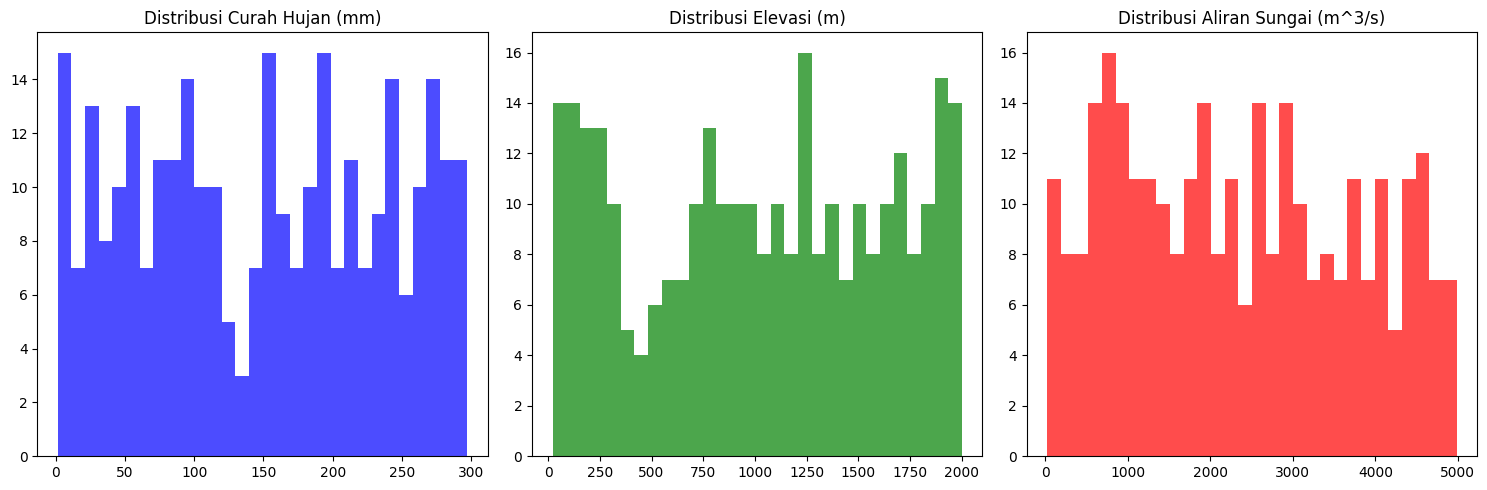

In [ ]:

import matplotlib.pyplot as plt

# Plotting distribution of Rainfall, Elevation, and River Flow
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(dummy_df["Rainfall (mm)"], bins=30, color='blue', alpha=0.7)
plt.title("Distribusi Curah Hujan (mm)")

plt.subplot(1, 3, 2)
plt.hist(dummy_df["Elevation (m)"], bins=30, color='green', alpha=0.7)
plt.title("Distribusi Elevasi (m)")

plt.subplot(1, 3, 3)
plt.hist(dummy_df["River Flow (m^3/s)"], bins=30, color='red', alpha=0.7)
plt.title("Distribusi Aliran Sungai (m^3/s)")

plt.tight_layout()
plt.show()


## Langkah 3: Preprocessing Data
Sebelum melatih model, data harus diproses agar sesuai dengan kebutuhan model machine learning. Ini termasuk pemilihan fitur yang relevan dan penghapusan nilai yang hilang, serta normalisasi untuk memastikan bahwa semua fitur memiliki skala yang seragam.

In [ ]:

from sklearn.preprocessing import MinMaxScaler

# Selecting features (X) and target variable (y)
X = dummy_df[["Rainfall (mm)", "Elevation (m)", "River Flow (m^3/s)"]]
y = dummy_df["Flood Status"]

# Feature scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Show the first few rows of the scaled data
X_scaled[:5]


array([[0.37510806, 0.04130336, 0.16558763],
       [0.96006106, 0.52637021, 0.27610024],
       [0.73800819, 0.53575505, 0.17372619],
       [0.60264118, 0.63363829, 0.08472781],
       [0.1532571 , 0.72329673, 0.11691082]])

## Langkah 4: Pembagian Data Train dan Test
Setelah preprocessing, kita akan membagi dataset menjadi dua bagian: satu untuk pelatihan model (train) dan satu lagi untuk menguji akurasi model (test). Pembagian ini penting untuk mengevaluasi kinerja model.

In [ ]:
from sklearn.model_selection import train_test_split

# Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42)

# Display the shape of the train and test sets
X_train.shape, X_test.shape


((210, 3), (90, 3))

## Langkah 5: Melatih Model
Sekarang kita akan melatih model menggunakan algoritma Support Vector Classifier (SVC). Algoritma ini digunakan untuk klasifikasi biner, di sini untuk memprediksi apakah banjir akan terjadi atau tidak berdasarkan data yang diberikan.

In [ ]:
from sklearn.svm import SVC
# Train a Support Vector Classifier model
model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)

# Check the accuracy on the training data
train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

train_accuracy, test_accuracy


(0.7, 0.6)

## Langkah 6: Evaluasi Model
Setelah melatih model, kita akan mengevaluasi kinerjanya menggunakan metrik klasifikasi seperti akurasi dan laporan klasifikasi. Ini memberikan gambaran tentang seberapa baik model dalam memprediksi apakah banjir akan terjadi.

In [ ]:
from sklearn.metrics import classification_report
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
classification_report(y_test, y_pred)


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


'              precision    recall  f1-score   support\n\n           0       0.00      0.00      0.00        36\n           1       0.60      1.00      0.75        54\n\n    accuracy                           0.60        90\n   macro avg       0.30      0.50      0.38        90\nweighted avg       0.36      0.60      0.45        90\n'

## Langkah 7: Prediksi
Model yang sudah dilatih sekarang dapat digunakan untuk memprediksi apakah banjir akan terjadi pada data baru yang belum terlihat sebelumnya. Prediksi ini dapat digunakan untuk memberikan peringatan dini kepada masyarakat.

In [ ]:

# Example prediction for a new observation (e.g., high rainfall, low elevation, and high river flow)
new_data = np.array([[150, 500, 3000]])  # Example new data (Rainfall=150mm, Elevation=500m, River Flow=3000m^3/s)

# Scale the new data
new_data_scaled = scaler.transform(new_data)

# Predict flood status
flood_prediction = model.predict(new_data_scaled)
flood_prediction


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([1])


## Keterangan Penting

Notebook ini menggunakan data dummy. Agar model ini dapat menghasilkan prediksi yang lebih akurat dan relevan, **kustomisasi lebih lanjut diperlukan**. Beberapa hal yang perlu dipertimbangkan antara lain:

1. **Penyempurnaan Dataset**: Data yang digunakan adalah data dummy yang bersifat acak. Untuk hasil yang lebih baik, dataset harus diisi dengan data kemacetan lalu lintas yang lebih realistis dan sesuai dengan kondisi lokal yang relevan.
   
2. **Penyesuaian Fitur**: Beberapa fitur, seperti jumlah kendaraan, kecepatan rata-rata, atau status sinyal lalu lintas, perlu penyesuaian atau penambahan fitur lain yang lebih berdampak pada prediksi kemacetan.

3. **Parameter Model**: Untuk hasil prediksi yang lebih optimal, Anda dapat menyesuaikan parameter model SVM atau mencoba model lain yang lebih sesuai dengan karakteristik data.

4. **Validasi Model**: Melakukan validasi dengan data nyata dan cross-validation untuk mengevaluasi kinerja model.

Dengan penyesuaian yang tepat, model ini dapat memberikan prediksi kemacetan yang lebih akurat dan bermanfaat untuk mengatur lalu lintas di kota dan meningkatkan mobilitas perkotaan.
